In [9]:
!pip install --upgrade yfinance
!pip install pandas

In [4]:
import yfinance as yf
import psycopg2

# เทสต์แค่ 5 ตัวที่เป็นหุ้นใหญ่ (ถ้า 5 ตัวนี้ยังไม่ได้ แปลว่าปัญหาอยู่ที่ yfinance ไม่ใช่ที่ Database)
test_symbols = ["PTT", "AOT", "CPALL", "ADVANC", "DELTA"]

print("🔍 กำลังทดสอบดึงข้อมูลแบบละเอียด...")

for sym in test_symbols:
    try:
        print(f"\nกำลังดึงข้อมูล: {sym}.BK")
        ticker = yf.Ticker(f"{sym}.BK")
        
        # ลองดึงข้อมูล info ออกมาดูตรงๆ
        info = ticker.info
        
        sector = info.get('sector', 'ไม่พบข้อมูล Sector')
        mcap = info.get('marketCap', 'ไม่พบข้อมูล Market Cap')
        
        print(f"✅ สำเร็จ! -> Sector: {sector}, Market Cap: {mcap}")
        
    except Exception as e:
        # คราวนี้ถ้าพัง มันจะโชว์ Error ออกมาสีแดงๆ ให้เราเห็นเลย
        print(f"❌ พังตรงนี้! -> {e}")

🔍 กำลังทดสอบดึงข้อมูลแบบละเอียด...

กำลังดึงข้อมูล: PTT.BK
✅ สำเร็จ! -> Sector: Energy, Market Cap: 1033838264320

กำลังดึงข้อมูล: AOT.BK
✅ สำเร็จ! -> Sector: Industrials, Market Cap: 807142031360

กำลังดึงข้อมูล: CPALL.BK
✅ สำเร็จ! -> Sector: Consumer Defensive, Market Cap: 463606153216

กำลังดึงข้อมูล: ADVANC.BK
✅ สำเร็จ! -> Sector: Communication Services, Market Cap: 1156967563264

กำลังดึงข้อมูล: DELTA.BK
✅ สำเร็จ! -> Sector: Industrials, Market Cap: 3180823052288


In [ ]:
import yfinance as yf
import psycopg2
import time

# 1. เชื่อมต่อ Database
conn = psycopg2.connect(host="127.0.0.1", database="thai_stocks_db", user="postgres", password="Shifa.326459")
conn.autocommit = True
cur = conn.cursor()

print("🔧 กำลังอัปเดตโครงสร้าง Database ให้รองรับ Market Cap...")

# 2. เพิ่มคอลัมน์ market_cap 
cur.execute("CREATE TABLE IF NOT EXISTS sectors (sector_id SERIAL PRIMARY KEY, sector_name VARCHAR(100) UNIQUE NOT NULL);")
cur.execute("CREATE TABLE IF NOT EXISTS stocks (symbol VARCHAR(20) PRIMARY KEY, sector_id INTEGER REFERENCES sectors(sector_id));")

cur.execute("ALTER TABLE stocks ADD COLUMN IF NOT EXISTS market_cap NUMERIC;")

print("✅ อัปเดตโครงสร้าง Database สำเร็จ!")

# 3. เริ่มดึงข้อมูล
all_thai_symbols = [
    "ADVANC", "AOT", "BBL", "BDMS", "BEM", "BGRIM", "BH", "BTS", "CBG", "CPALL", 
    "CPF", "CPN", "CRC", "DELTA", "EA", "EGCO", "GLOBAL", "GPSC", "GULF", "HMPRO", 
    "INTUCH", "IVL", "KBANK", "KTB", "KTC", "LH", "MINT", "MTC", "OR", "OSP", 
    "PTT", "PTTEP", "PTTGC", "RATCH", "SAWAD", "SCB", "SCC", "SCGP", "TISCO", "TOP", 
    "TRUE", "TTB", "TU", "WHA", "AMATA", "AP", "AWC", "BAM", "BANPU", "BCH", 
    "BCP", "BCPG", "BLA", "BPP", "CENTEL", "CHG", "CK", "CKP", "COM7", "DOHOME", 
    "EPG", "ERW", "FORTH", "HANA", "ICHI", "ILM", "JAS", "JMART", "JMT", 
    "KCE", "KKP", "MEGA", "ONEE", "ORI", "PLANB", "PSL", "PTG", "QH", "RBF", 
    "RCL", "RS", "SABINA", "SINGER", "SIRI", "SPALI", "SPRC", "STA", "STARK", "STEC", 
    "STGT", "SUPER", "SYNEX", "TASCO", "TCAP", "THANI", "THCOM", "THG", "TIDLOR", "TIPH", 
    "TKN", "TQM", "TTA", "VGI", "WICE", "XPG"
]

print(f"⏳ เริ่มต้นดึงข้อมูลหุ้น {len(all_thai_symbols)} ตัว ลง Database...")

success_count = 0

for sym in all_thai_symbols:
    try:
        ticker = yf.Ticker(f"{sym}.BK")
        info = ticker.info
        
        if 'marketCap' in info and info['marketCap'] is not None:
            sector_name = info.get('sector', 'Unknown')
            market_cap = info.get('marketCap', 0)
            
            # บันทึก Sector
            cur.execute("""
                INSERT INTO sectors (sector_name) VALUES (%s) 
                ON CONFLICT (sector_name) DO NOTHING;
            """, (sector_name,))
            
            cur.execute("SELECT sector_id FROM sectors WHERE sector_name = %s;", (sector_name,))
            s_id = cur.fetchone()[0]
            
            # บันทึก หุ้น
            cur.execute("""
                INSERT INTO stocks (symbol, sector_id, market_cap)
                VALUES (%s, %s, %s)
                ON CONFLICT (symbol) DO UPDATE 
                SET sector_id = EXCLUDED.sector_id, market_cap = EXCLUDED.market_cap;
            """, (sym, s_id, market_cap))
            
            success_count += 1
            print(f"✅ บันทึก {sym} สำเร็จ! (Sector: {sector_name})")
            
        time.sleep(0.1)
        
    except Exception as e:
        print(f"⚠️ ข้าม {sym} -> หาข้อมูลไม่พบ หรือ Error: {e}")

print(f"\n🎉 สำเร็จแล้ว! ดึงข้อมูลและบันทึกลง Database ได้ทั้งหมด {success_count} ตัว!")

🔧 กำลังอัปเดตโครงสร้าง Database ให้รองรับ Market Cap...
✅ อัปเดตโครงสร้าง Database สำเร็จ!
⏳ เริ่มต้นดึงข้อมูลหุ้น 105 ตัว ลง Database...
✅ บันทึก ADVANC สำเร็จ! (Sector: Communication Services)
✅ บันทึก AOT สำเร็จ! (Sector: Industrials)
✅ บันทึก BBL สำเร็จ! (Sector: Financial Services)
✅ บันทึก BDMS สำเร็จ! (Sector: Healthcare)
✅ บันทึก BEM สำเร็จ! (Sector: Industrials)
✅ บันทึก BGRIM สำเร็จ! (Sector: Utilities)
✅ บันทึก BH สำเร็จ! (Sector: Healthcare)
✅ บันทึก BTS สำเร็จ! (Sector: Industrials)
✅ บันทึก CBG สำเร็จ! (Sector: Consumer Defensive)
✅ บันทึก CPALL สำเร็จ! (Sector: Consumer Defensive)
✅ บันทึก CPF สำเร็จ! (Sector: Consumer Defensive)
✅ บันทึก CPN สำเร็จ! (Sector: Real Estate)
✅ บันทึก CRC สำเร็จ! (Sector: Consumer Cyclical)
✅ บันทึก DELTA สำเร็จ! (Sector: Industrials)
✅ บันทึก EA สำเร็จ! (Sector: Utilities)
✅ บันทึก EGCO สำเร็จ! (Sector: Utilities)
✅ บันทึก GLOBAL สำเร็จ! (Sector: Consumer Cyclical)
✅ บันทึก GPSC สำเร็จ! (Sector: Utilities)
✅ บันทึก GULF สำเร็จ! (Sector: Uti

In [4]:
kbank = yf.Ticker("KBANK.BK")

In [5]:
kbank.info

{'address1': '400/22 Phahon Yothin Road',
 'address2': 'Sam Sen Nai Sub-District Phaya Thai District',
 'city': 'Bangkok',
 'zip': '10400',
 'country': 'Thailand',
 'phone': '66 2 222 0000',
 'fax': '66 2 470 1144',
 'website': 'https://www.kasikornbank.com',
 'industry': 'Banks - Regional',
 'industryKey': 'banks-regional',
 'industryDisp': 'Banks - Regional',
 'sector': 'Financial Services',
 'sectorKey': 'financial-services',
 'sectorDisp': 'Financial Services',
 'longBusinessSummary': 'Kasikornbank Public Company Limited provides commercial banking products and services in Thailand and internationally. Its personal banking products and services include savings, e-savings, current, fixed deposit, and foreign currency deposit accounts; personal, home, and auto loans; debit and credit cards; health, life, accident, travel, saving, retirement, and non-life insurance products; investment products, such as mutual funds, stocks, debentures/bonds, derivatives/futures exchange, and Wealth P

In [7]:
kbank.history(period = '1y')

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-02-26 00:00:00+07:00,142.579451,144.886561,137.965229,138.426651,19549200,0.0,0.0
2025-02-27 00:00:00+07:00,137.042365,142.118008,136.119521,139.810898,14083700,0.0,0.0
2025-02-28 00:00:00+07:00,138.888054,139.810898,137.042365,139.810898,14197400,0.0,0.0
2025-03-03 00:00:00+07:00,140.733749,142.118016,139.810905,140.733749,10293600,0.0,0.0
2025-03-04 00:00:00+07:00,140.733749,141.656594,138.426639,140.733749,8198900,0.0,0.0
...,...,...,...,...,...,...,...
2026-02-20 00:00:00+07:00,205.000000,206.000000,202.000000,205.000000,28943000,0.0,0.0
2026-02-23 00:00:00+07:00,204.000000,206.000000,199.500000,201.000000,20454700,0.0,0.0
2026-02-24 00:00:00+07:00,202.000000,202.000000,198.000000,201.000000,26551400,0.0,0.0


<Axes: xlabel='Date'>

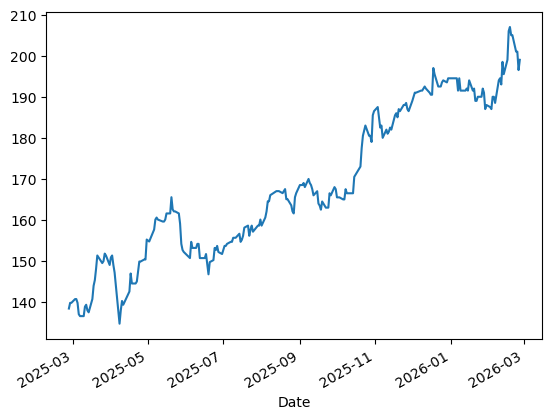

In [11]:
kbank.history(period = '1y')["Close"].plot()

In [12]:
kbank.calendar

{'Ex-Dividend Date': datetime.date(2025, 9, 10),
 'Earnings Date': [datetime.date(2026, 4, 21)],
 'Earnings High': 5.69,
 'Earnings Low': 4.97609,
 'Earnings Average': 5.33304,
 'Revenue High': 47996896000,
 'Revenue Low': 47996896000,
 'Revenue Average': 47996896000}

In [14]:
kbank.quarterly_income_stmt

,2025-09-30,2025-06-30,2025-03-31,2024-12-31,2024-09-30,2024-06-30
Tax Effect Of Unusual Items,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
Tax Rate For Calcs,1.990640e-01,1.962000e-01,2.067590e-01,1.938100e-01,2.063110e-01,NaN
Total Unusual Items,NaN,NaN,NaN,NaN,NaN,0.000000e+00
Total Unusual Items Excluding Goodwill,NaN,NaN,NaN,NaN,NaN,0.000000e+00
Net Income From Continuing Operation Net Minority Interest,1.300719e+10,1.248819e+10,1.379145e+10,1.049406e+10,1.229533e+10,NaN
Reconciled Depreciation,2.425158e+09,2.347252e+09,2.323653e+09,2.344136e+09,2.186675e+09,NaN
Net Interest Income,3.415815e+10,3.776700e+10,3.542541e+10,4.864645e+10,3.669277e+10,NaN
Interest Expense,8.901204e+09,6.171000e+09,9.537302e+09,-2.487204e+09,9.838034e+09,NaN
Interest Income,4.305935e+10,4.393800e+10,4.496272e+10,4.615924e+10,4.653081e+10,NaN
Normalized Income,1.300719e+10,1.248819e+10,1.379145e+10,1.049406e+10,1.229533e+10,NaN


In [15]:
kbank.quarterly_balance_sheet

,2025-09-30,2025-06-30,2025-03-31,2024-12-31,2024-09-30,2024-06-30
Ordinary Shares Number,2.369328e+09,2.369328e+09,2.369328e+09,2.369328e+09,2.369328e+09,NaN
Share Issued,2.369328e+09,2.369328e+09,2.369328e+09,2.369328e+09,2.369328e+09,NaN
Net Debt,2.083841e+11,NaN,2.166512e+11,NaN,1.801077e+11,NaN
Total Debt,2.530167e+11,1.941560e+11,2.543792e+11,1.855940e+11,2.134231e+11,NaN
Tangible Book Value,5.546408e+11,5.421481e+11,5.524860e+11,5.328826e+11,5.216235e+11,NaN
Invested Capital,8.389995e+11,7.674868e+11,8.383056e+11,7.489458e+11,7.645424e+11,NaN
Net Tangible Assets,5.546408e+11,5.421481e+11,5.524860e+11,5.328826e+11,5.216235e+11,NaN
Common Stock Equity,5.859829e+11,5.733308e+11,5.839265e+11,5.633518e+11,5.511193e+11,NaN
Total Capitalization,8.389995e+11,7.674868e+11,8.383056e+11,7.489458e+11,7.645424e+11,NaN
Total Equity Gross Minority Interest,6.733217e+11,6.541635e+11,6.613556e+11,6.316153e+11,6.187332e+11,NaN


In [16]:
kbank.quarterly_cash_flow

,2025-09-30,2025-06-30,2025-03-31,2024-12-31,2024-09-30,2024-06-30
Free Cash Flow,3.480160e+10,3.259769e+10,4.816494e+10,7.118008e+10,-2.855793e+10,NaN
Repayment Of Debt,-2.141310e+08,-2.873640e+08,-8.879230e+08,-2.507600e+08,-3.169340e+08,NaN
Issuance Of Debt,NaN,NaN,0.000000e+00,6.556000e+06,0.000000e+00,-78827000.0
Capital Expenditure,-1.537501e+09,-1.373360e+09,-2.372184e+09,-2.833798e+09,-2.003174e+09,NaN
End Cash Position,4.463262e+10,3.604080e+10,3.772795e+10,4.602138e+10,3.331541e+10,NaN
Beginning Cash Position,3.604080e+10,3.772795e+10,4.602138e+10,3.331541e+10,3.026458e+10,NaN
Effect Of Exchange Rate Changes,8.435000e+06,-5.546900e+07,2.798900e+07,7.641000e+06,-1.574160e+08,NaN
Changes In Cash,8.583377e+09,-1.631678e+09,-8.321417e+09,1.269833e+10,3.208251e+09,NaN
Financing Cash Flow,-5.904598e+09,-2.652368e+10,-8.880110e+08,-6.700480e+08,-3.870925e+09,NaN
Cash Flow From Continuing Financing Activities,-5.904598e+09,-2.652368e+10,-8.880110e+08,-6.700480e+08,-3.870925e+09,NaN


In [17]:
import yfinance as yf
import psycopg2
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

# 1. เชื่อมต่อ Database
conn = psycopg2.connect(host="127.0.0.1", database="thai_stocks_db", user="postgres", password="Shifa.326459")
conn.autocommit = True
cur = conn.cursor()

print("🔧 กำลังสร้างตารางใหม่สำหรับข้อมูลพื้นฐานและงบการเงิน...")

# 2. สร้างตาราง company_profiles
cur.execute("""
CREATE TABLE IF NOT EXISTS company_profiles (
    symbol VARCHAR(20) PRIMARY KEY REFERENCES stocks(symbol),
    company_name VARCHAR(255),
    industry VARCHAR(100),
    website VARCHAR(255),
    trailing_pe NUMERIC,
    dividend_yield NUMERIC,
    next_earnings_date DATE
);
""")

# 3. สร้างตาราง quarterly_financials
cur.execute("""
CREATE TABLE IF NOT EXISTS quarterly_financials (
    symbol VARCHAR(20) REFERENCES stocks(symbol),
    quarter_end_date DATE,
    total_revenue NUMERIC,
    gross_profit NUMERIC,
    net_income NUMERIC,
    PRIMARY KEY (symbol, quarter_end_date)
);
""")
print("✅ สร้างตารางสำเร็จ!")

# 4. ดึงรายชื่อหุ้นจาก Database มาอัปเดตข้อมูล
cur.execute("SELECT symbol FROM stocks;")
symbols = [row[0] for row in cur.fetchall()]

# ตัดให้เหลือ 10 ตัวแรกก่อนเพื่อความรวดเร็วในการเทสต์ระบบ (ถ้าอยากดึงหมดให้ลบ [:10] ออกครับ)
test_symbols = symbols[:10] 

print(f"⏳ เริ่มโหลดข้อมูล Profile & Financials สำหรับหุ้น {len(test_symbols)} ตัว...")

success_count = 0

for sym in test_symbols:
    try:
        ticker = yf.Ticker(f"{sym}.BK")
        
        # -----------------------------------------
        # ส่วนที่ 1: ดึงข้อมูลจาก .info และ .calendar
        # -----------------------------------------
        info = ticker.info
        
        comp_name = info.get('longName', '')
        industry = info.get('industry', '')
        website = info.get('website', '')
        pe = info.get('trailingPE', None)
        div_yield = info.get('dividendYield', None)
        
        # แปลง Yield ให้เป็น % (ถ้ามีค่า)
        if div_yield is not None:
            div_yield = div_yield * 100
            
        # ดึงวันที่ประกาศงบครั้งถัดไปจาก calendar
        # yfinance บางเวอร์ชัน calendar จะมาเป็น dict
        cal = ticker.calendar
        next_earn_date = None
        if isinstance(cal, dict) and 'Earnings Date' in cal:
            next_earn_date = cal['Earnings Date'][0] if len(cal['Earnings Date']) > 0 else None

        # UPSERT ลง company_profiles
        cur.execute("""
            INSERT INTO company_profiles (symbol, company_name, industry, website, trailing_pe, dividend_yield, next_earnings_date)
            VALUES (%s, %s, %s, %s, %s, %s, %s)
            ON CONFLICT (symbol) DO UPDATE 
            SET company_name = EXCLUDED.company_name, industry = EXCLUDED.industry, 
                trailing_pe = EXCLUDED.trailing_pe, dividend_yield = EXCLUDED.dividend_yield;
        """, (sym, comp_name, industry, website, pe, div_yield, next_earn_date))

        # -----------------------------------------
        # ส่วนที่ 2: ดึงข้อมูลงบจาก .quarterly_income_stmt
        # -----------------------------------------
        q_income = ticker.quarterly_income_stmt
        
        if not q_income.empty:
            # yfinance จะคืนค่ามาโดยให้ "วันที่" เป็นคอลัมน์ และ "รายการบัญชี" เป็น index (แถว)
            # เราต้องลูปตามคอลัมน์ (วันที่)
            for date_col in q_income.columns:
                q_date = date_col.date()
                
                # ดึงข้อมูลแต่ละรายการ (ใช้ .get ป้องกัน error ถ้าไม่มีบรรทัดนั้น)
                tot_rev = q_income[date_col].get('Total Revenue', 0)
                gross_p = q_income[date_col].get('Gross Profit', 0)
                net_inc = q_income[date_col].get('Net Income', 0)
                
                # แปลงค่า NaN เป็น 0 หรือ None เพื่อให้ SQL ไม่พัง
                tot_rev = float(tot_rev) if pd.notna(tot_rev) else 0
                gross_p = float(gross_p) if pd.notna(gross_p) else 0
                net_inc = float(net_inc) if pd.notna(net_inc) else 0

                # UPSERT ลง quarterly_financials
                cur.execute("""
                    INSERT INTO quarterly_financials (symbol, quarter_end_date, total_revenue, gross_profit, net_income)
                    VALUES (%s, %s, %s, %s, %s)
                    ON CONFLICT (symbol, quarter_end_date) DO UPDATE 
                    SET total_revenue = EXCLUDED.total_revenue, gross_profit = EXCLUDED.gross_profit, net_income = EXCLUDED.net_income;
                """, (sym, q_date, tot_rev, gross_p, net_inc))
        
        print(f"✅ ดึงข้อมูล {sym} สำเร็จ")
        success_count += 1
        time.sleep(0.5) # พักเซิร์ฟเวอร์
        
    except Exception as e:
        print(f"⚠️ ข้าม {sym}: {e}")

print(f"\n🎉 อัปเดตข้อมูลทั่วไปและงบการเงินสำเร็จ {success_count} ตัว!")

conn.close()

🔧 กำลังสร้างตารางใหม่สำหรับข้อมูลพื้นฐานและงบการเงิน...
✅ สร้างตารางสำเร็จ!
⏳ เริ่มโหลดข้อมูล Profile & Financials สำหรับหุ้น 10 ตัว...
✅ ดึงข้อมูล ADVANC สำเร็จ
✅ ดึงข้อมูล AOT สำเร็จ
✅ ดึงข้อมูล BBL สำเร็จ
✅ ดึงข้อมูล BDMS สำเร็จ
✅ ดึงข้อมูล BEM สำเร็จ
✅ ดึงข้อมูล BGRIM สำเร็จ
✅ ดึงข้อมูล BH สำเร็จ
✅ ดึงข้อมูล BTS สำเร็จ
✅ ดึงข้อมูล CBG สำเร็จ
✅ ดึงข้อมูล CPALL สำเร็จ

🎉 อัปเดตข้อมูลทั่วไปและงบการเงินสำเร็จ 10 ตัว!


⏳ กำลังดึงข้อมูลราคาประวัติศาสตร์ 1 ปี ของหุ้น 102 ตัว...


### 🎯 Calculate SET Index (Custom Market-Cap Weighted)

✅ คำนวณดัชนีจำลอง (Custom SET Index) สำเร็จ! (จุดเริ่มต้น 1000 จุด)


,Custom SET Index
Date,
2026-02-20,1442.415101
2026-02-23,1451.499557
2026-02-24,1462.655306
2026-02-25,1494.249407
2026-02-26,1509.598388


### 🎯 Plot SET Index

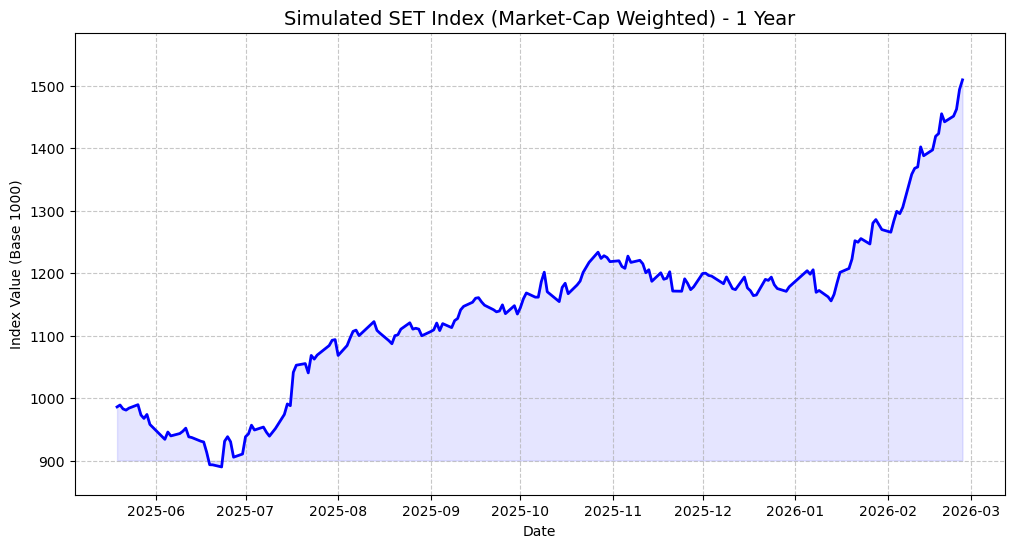

### 🎯 Plot Candlestick of any stocks (ตัวอย่าง: PTT)

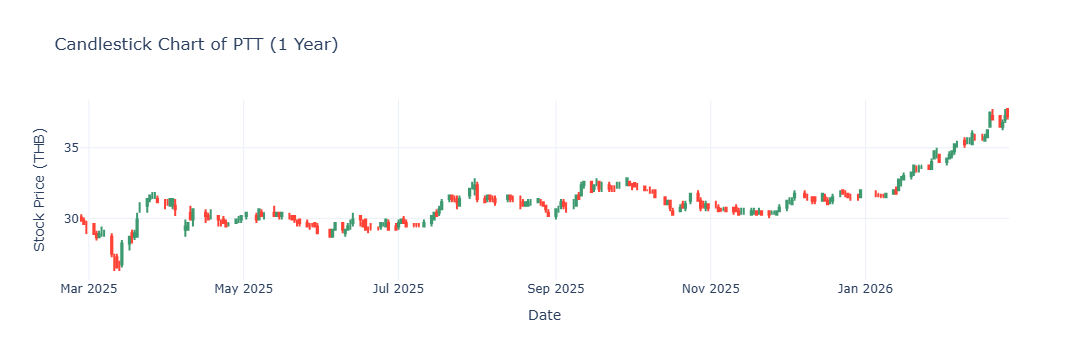

In [18]:
import psycopg2
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

def print_topic(text):
    display(Markdown(f"### 🎯 {text}"))

# ==========================================
# 1. ดึงข้อมูลจาก Database
# ==========================================
conn = psycopg2.connect(host="127.0.0.1", database="thai_stocks_db", user="postgres", password="Shifa.326459")
cur = conn.cursor()

# ดึงชื่อหุ้นและ Market Cap ออกมาเพื่อใช้ถ่วงน้ำหนัก (Weighting)
df_stocks = pd.read_sql("SELECT symbol, market_cap FROM stocks WHERE market_cap > 0;", conn)
symbols = df_stocks['symbol'].tolist()
tickers = [f"{sym}.BK" for sym in symbols]

print(f"⏳ กำลังดึงข้อมูลราคาประวัติศาสตร์ 1 ปี ของหุ้น {len(symbols)} ตัว...")
# ดึงข้อมูลย้อนหลัง 1 ปี
hist_data = yf.download(tickers, period="1y", progress=False)

# ==========================================
# 2. Calculate & Plot SET Index (Simulated)
# ==========================================
print_topic("Calculate SET Index (Custom Market-Cap Weighted)")

# ดึงราคาปิด (Close) ของทุกตัว
df_close = hist_data['Close'].copy()
df_close.columns = [c.replace('.BK', '') for c in df_close.columns]

# คำนวณผลตอบแทนรายวัน (Daily Return) ของหุ้นแต่ละตัว
df_returns = df_close.pct_change().dropna()

# คำนวณน้ำหนัก (Weight) ของหุ้นแต่ละตัวจาก Market Cap
total_mcap = df_stocks['market_cap'].sum()
df_stocks['weight'] = df_stocks['market_cap'] / total_mcap

# จัด index ของ weight ให้ตรงกับ columns ของ df_returns
weights = df_stocks.set_index('symbol')['weight']
# กรองเฉพาะ weight ของหุ้นที่มีใน df_returns
weights = weights[df_returns.columns]
# ปรับ weight รวมให้เป็น 1 อีกครั้ง (กรณีมีหุ้นบางตัวดึงราคาไม่ได้)
weights = weights / weights.sum()

# คำนวณผลตอบแทนของ Index รายวัน = Sum(Return หุ้น * Weight หุ้น)
index_daily_returns = (df_returns * weights).sum(axis=1)

# สร้าง Index โดยให้วันแรกมีค่า = 1000 จุด
# สูตร: Index ปัจจุบัน = Index ก่อนหน้า * (1 + Daily Return)
custom_set_index = 1000 * (1 + index_daily_returns).cumprod()

print("✅ คำนวณดัชนีจำลอง (Custom SET Index) สำเร็จ! (จุดเริ่มต้น 1000 จุด)")
display(pd.DataFrame({"Custom SET Index": custom_set_index}).tail())

print_topic("Plot SET Index")
plt.figure(figsize=(12, 6))
plt.plot(custom_set_index.index, custom_set_index.values, color='blue', linewidth=2)
plt.title('Simulated SET Index (Market-Cap Weighted) - 1 Year', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Index Value (Base 1000)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.fill_between(custom_set_index.index, custom_set_index.values, 900, color='blue', alpha=0.1)
plt.ylim(custom_set_index.min() * 0.95, custom_set_index.max() * 1.05)
plt.show()

# ==========================================
# 3. Plot Candlestick of any stocks
# ==========================================
print_topic("Plot Candlestick of any stocks (ตัวอย่าง: PTT)")

# เลือกหุ้นมา 1 ตัว (เช่น PTT)
target_stock = "PTT.BK"
df_candle = hist_data.xs(target_stock, axis=1, level=1) if isinstance(hist_data.columns, pd.MultiIndex) else hist_data

# สำหรับ yfinance เวอร์ชั่นใหม่ที่ MultiIndex อาจจะสลับชั้น
if 'Close' in hist_data.columns.levels[0]:
    df_candle = pd.DataFrame({
        'Open': hist_data['Open'][target_stock],
        'High': hist_data['High'][target_stock],
        'Low': hist_data['Low'][target_stock],
        'Close': hist_data['Close'][target_stock],
        'Volume': hist_data['Volume'][target_stock]
    }).dropna()

# ใช้ Plotly วาดกราฟแท่งเทียน (Interactive)
fig = go.Figure(data=[go.Candlestick(x=df_candle.index,
                open=df_candle['Open'],
                high=df_candle['High'],
                low=df_candle['Low'],
                close=df_candle['Close'],
                name='Candlestick')])

fig.update_layout(
    title=f'Candlestick Chart of {target_stock.replace(".BK", "")} (1 Year)',
    yaxis_title='Stock Price (THB)',
    xaxis_title='Date',
    template='plotly_white',
    xaxis_rangeslider_visible=False # ปิดแถบเลื่อนด้านล่างให้กราฟดูสะอาดตา
)

fig.show()

✅ อัปเดตโครงสร้างตารางรองรับ SET50, SET100 แล้ว
⏳ กำลังดึงข้อมูลราคาประวัติศาสตร์ 1 ปี...


### 🎯 Plot SET, SET50, SET100 and Sector Indices

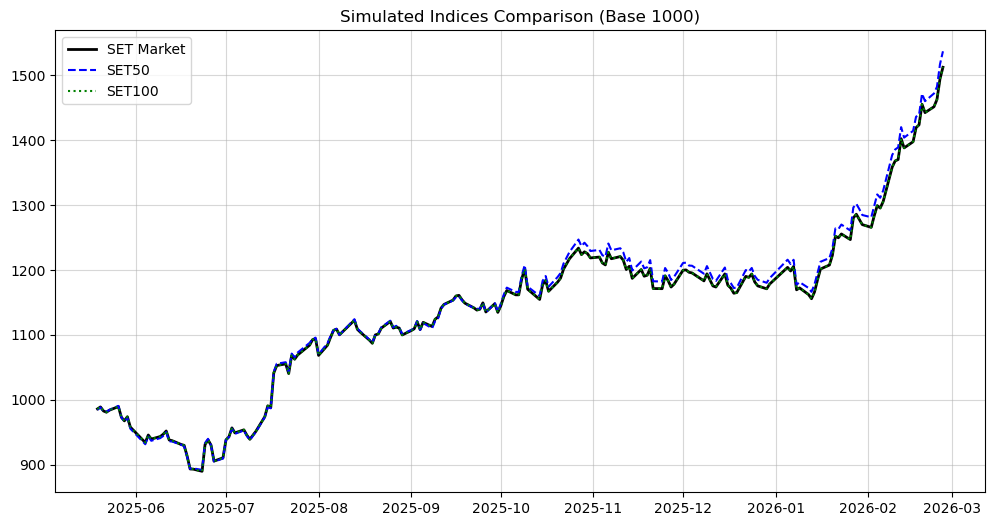

### 🎯 Which stocks move nearest to the SET index most?

🏆 5 อันดับวิ่งตามตลาดมากที่สุด (Correlation ใกล้ 1.0):


,Correlation
DELTA,0.850726
GULF,0.674929
MTC,0.575473
AWC,0.574727
CPALL,0.549805



🔻 5 อันดับวิ่งไม่สนตลาด (Correlation ต่ำสุด):


,Correlation
THG,0.194938
ONEE,0.168921
XPG,0.154027
SUPER,0.138300
RS,0.076877


In [21]:
# ==========================================
# 1. แก้ไข Schema (เพิ่มคอลัมน์สถานะดัชนี)
# ==========================================
cur.execute("""
    ALTER TABLE stocks 
    ADD COLUMN IF NOT EXISTS is_set50 BOOLEAN DEFAULT FALSE,
    ADD COLUMN IF NOT EXISTS is_set100 BOOLEAN DEFAULT FALSE,
    ADD COLUMN IF NOT EXISTS is_mai BOOLEAN DEFAULT FALSE;
""")
print("✅ อัปเดตโครงสร้างตารางรองรับ SET50, SET100 แล้ว")

# ==========================================
# 2. อัปเดตข้อมูล SET50 / SET100
# ==========================================
set50_symbols = [
    "ADVANC", "AOT", "BBL", "BDMS", "BEM", "BGRIM", "BH", "BTS", "CBG", "CPALL", 
    "CPF", "CPN", "CRC", "DELTA", "EA", "EGCO", "GLOBAL", "GPSC", "GULF", "HMPRO", 
    "INTUCH", "IVL", "KBANK", "KTB", "KTC", "LH", "MINT", "MTC", "OR", "OSP", 
    "PTT", "PTTEP", "PTTGC", "RATCH", "SAWAD", "SCB", "SCC", "SCGP", "TISCO", "TOP", 
    "TRUE", "TTB", "TU", "WHA"
]

cur.execute("UPDATE stocks SET is_set50 = FALSE, is_set100 = TRUE;") 
for sym in set50_symbols:
    cur.execute("UPDATE stocks SET is_set50 = TRUE WHERE symbol = %s;", (sym,))

# ==========================================
# 3. เตรียมข้อมูลและคำนวณ Index
# ==========================================
df_stocks = pd.read_sql("""
    SELECT symbol, market_cap, is_set50, is_set100, sector_name 
    FROM stocks st JOIN sectors s ON st.sector_id = s.sector_id 
    WHERE market_cap > 0;
""", conn)

tickers = [f"{sym}.BK" for sym in df_stocks['symbol']]
print("⏳ กำลังดึงข้อมูลราคาประวัติศาสตร์ 1 ปี...")
hist_data = yf.download(tickers, period="1y", progress=False)['Close']
hist_data.columns = [c.replace('.BK', '') for c in hist_data.columns]
df_returns = hist_data.pct_change().dropna()

# ฟังก์ชันคำนวณ Index
def calculate_index(target_symbols):
    valid_syms = [s for s in target_symbols if s in df_returns.columns]
    if not valid_syms: return None
    subset_mcap = df_stocks[df_stocks['symbol'].isin(valid_syms)].set_index('symbol')['market_cap']
    weights = subset_mcap / subset_mcap.sum()
    idx_returns = (df_returns[valid_syms] * weights).sum(axis=1)
    return 1000 * (1 + idx_returns).cumprod() # เริ่มที่ 1000 จุด

set_index = calculate_index(df_stocks['symbol'].tolist())
set50_index = calculate_index(df_stocks[df_stocks['is_set50'] == True]['symbol'].tolist())
set100_index = calculate_index(df_stocks[df_stocks['is_set100'] == True]['symbol'].tolist())
bank_index = calculate_index(df_stocks[df_stocks['sector_name'] == 'BANK']['symbol'].tolist())
energ_index = calculate_index(df_stocks[df_stocks['sector_name'] == 'ENERG']['symbol'].tolist())

# ==========================================
# 4. พล็อตกราฟเปรียบเทียบดัชนี
# ==========================================
print_topic("Plot SET, SET50, SET100 and Sector Indices")

plt.figure(figsize=(12, 6))
plt.plot(set_index, label='SET Market', color='black', linewidth=2)
plt.plot(set50_index, label='SET50', color='blue', linestyle='--')
plt.plot(set100_index, label='SET100', color='green', linestyle=':')
if bank_index is not None: plt.plot(bank_index, label='BANK Sector', alpha=0.7)
if energ_index is not None: plt.plot(energ_index, label='ENERG Sector', alpha=0.7)

plt.title('Simulated Indices Comparison (Base 1000)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# ==========================================
# 5. หาหุ้นที่วิ่งตาม SET มากที่สุด (Correlation)
# ==========================================
print_topic("Which stocks move nearest to the SET index most?")
set_daily_returns = set_index.pct_change().dropna()

correlations = {sym: df_returns[sym].corr(set_daily_returns) for sym in df_returns.columns}
df_corr = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation']).sort_values(by='Correlation', ascending=False)

print("🏆 5 อันดับวิ่งตามตลาดมากที่สุด (Correlation ใกล้ 1.0):")
display(df_corr.head(5))

print("\n🔻 5 อันดับวิ่งไม่สนตลาด (Correlation ต่ำสุด):")
display(df_corr.tail(5))